# Figures 3 and 7: VAR Benchmark Results

**Figure 3** — F1, Precision, and Recall of M-CaStLe and baselines across numbers of variables on synthetic VAR data.  
**Figure 7** — Extent of benchmark parameter space: maximum number of links achieved with 30 replicates per variable count.

**Data required:**  
- `../data/figures/var_benchmark_data.csv` — pre-extracted benchmark metrics (n_vars, Method, F1, Precision, Recall)

Figures are saved to `figures/` relative to this notebook.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

## Figure 3: VAR Benchmark F1 / Precision / Recall

In [2]:
df = pd.read_csv("../data/figures/var_benchmark_data.csv")

CART_LABEL = "Cartesian-CaStLe"

ALL_METHODS_ORDER = [
    "M-CaStLe-PC",
    "M-CaStLe-PCMCI",
    "M-CaStLe-DYNOTEARS",
    f"{CART_LABEL}-PC",
    f"{CART_LABEL}-PCMCI",
    f"{CART_LABEL}-DYNOTEARS",
    "PC",
    "PCMCI",
    "DYNOTEARS",
]

ALL_PALETTE = {
    "M-CaStLe-PC":              "tab:blue",
    f"{CART_LABEL}-PC":         "tab:blue",
    "PC":                       "tab:blue",
    "M-CaStLe-PCMCI":           "tab:orange",
    f"{CART_LABEL}-PCMCI":      "tab:orange",
    "PCMCI":                    "tab:orange",
    "M-CaStLe-DYNOTEARS":       "tab:green",
    f"{CART_LABEL}-DYNOTEARS":  "tab:green",
    "DYNOTEARS":                "tab:green",
}

ALL_DASHES = {
    "M-CaStLe-PC":              (1, 0),
    "M-CaStLe-PCMCI":           (1, 0),
    "M-CaStLe-DYNOTEARS":       (1, 0),
    f"{CART_LABEL}-PC":         (5, 2),
    f"{CART_LABEL}-PCMCI":      (5, 2),
    f"{CART_LABEL}-DYNOTEARS":  (5, 2),
    "PC":                       (1, 1),
    "PCMCI":                    (1, 1),
    "DYNOTEARS":                (1, 1),
}

ALL_MARKERS = {
    "M-CaStLe-PC":              "o",
    "M-CaStLe-PCMCI":           "o",
    "M-CaStLe-DYNOTEARS":       "o",
    f"{CART_LABEL}-PC":         "s",
    f"{CART_LABEL}-PCMCI":      "s",
    f"{CART_LABEL}-DYNOTEARS":  "s",
    "PC":                       "^",
    "PCMCI":                    "^",
    "DYNOTEARS":                "^",
}

MARKER_SIZE = 16

all_df = df.copy()
all_df["Method"] = pd.Categorical(
    all_df["Method"], categories=ALL_METHODS_ORDER, ordered=True
)

In [3]:
def make_factorized_legend_handles(cart_label=CART_LABEL):
    color_handles = [
        Line2D([0], [0], color="tab:blue",   lw=2.5, linestyle="-", label="PC"),
        Line2D([0], [0], color="tab:orange", lw=2.5, linestyle="-", label="PCMCI"),
        Line2D([0], [0], color="tab:green",  lw=2.5, linestyle="-", label="DYNOTEARS"),
    ]
    style_handles = [
        Line2D([0], [0], color="gray", lw=2.5, linestyle="-",
               marker="o", markersize=8, label="M-CaStLe"),
        Line2D([0], [0], color="gray", lw=2.5, linestyle=(0, (5, 2)),
               marker="s", markersize=8, label=cart_label),
        Line2D([0], [0], color="gray", lw=2.5, linestyle=(0, (1, 1)),
               marker="^", markersize=8, label="Baseline"),
    ]
    return color_handles, style_handles

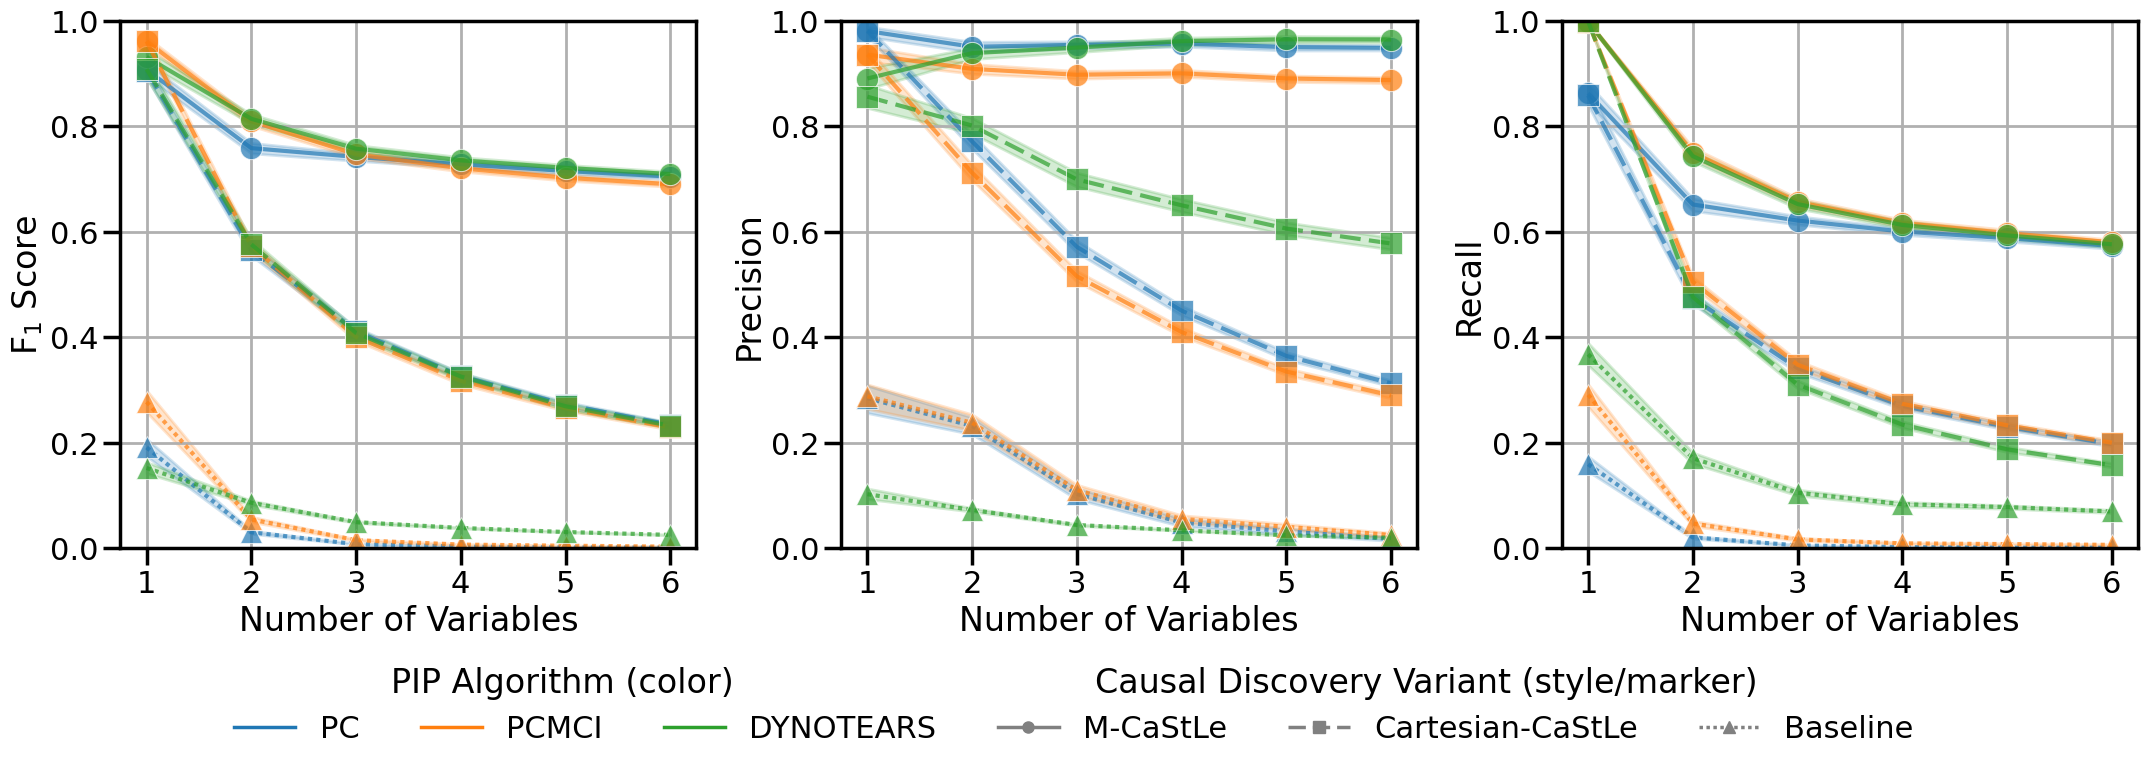

Wrote: figures/figure3_var_benchmark.pdf


In [4]:
METRICS = [
    ("F1",        r"F$_1$ Score"),
    ("Precision", "Precision"),
    ("Recall",    "Recall"),
]

with sns.plotting_context("poster"):
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False)

    for ax, (metric, ylabel) in zip(axes, METRICS):
        sns.lineplot(
            data=all_df,
            x="n_vars",
            y=metric,
            hue="Method",
            hue_order=ALL_METHODS_ORDER,
            style="Method",
            style_order=ALL_METHODS_ORDER,
            dashes=ALL_DASHES,
            markers=ALL_MARKERS,
            markersize=MARKER_SIZE,
            palette=ALL_PALETTE,
            errorbar=("ci", 95),
            estimator="mean",
            alpha=0.7,
            ax=ax,
        )
        ax.set(xlabel="Number of Variables", ylabel=ylabel)
        ax.set_xticks(sorted(all_df["n_vars"].unique()))
        ax.set_ylim(0, 1)
        ax.grid(True)
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    color_handles, style_handles = make_factorized_legend_handles()
    fig.legend(
        handles=color_handles + style_handles,
        ncol=6,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.14),
        frameon=False,
        title="PIP Algorithm (color)                                  Causal Discovery Variant (style/marker)",
    )

    plt.tight_layout()
    plt.savefig(figures_dir / "figure3_var_benchmark.pdf", bbox_inches="tight")
    plt.savefig(figures_dir / "figure3_var_benchmark.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"Wrote: {figures_dir / 'figure3_var_benchmark.pdf'}")

## Figure 7: Benchmark Parameter Extent (Link Counts)

Maximum number of causal links achieved with 30 replicates, for each number of variables.
Values are taken directly from the paper's experimental setup.

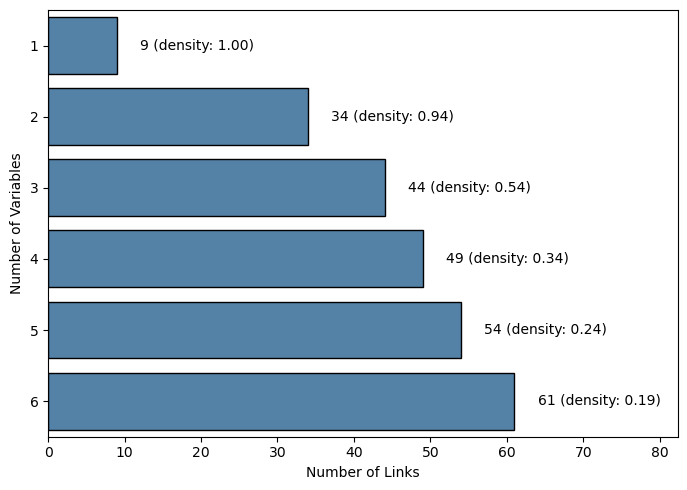

Wrote: figures/figure7_link_extents.pdf


In [5]:
max_links_data = pd.DataFrame({
    "Number of Variables": [1, 2, 3, 4, 5, 6],
    "Number of Links":     [9, 34, 44, 49, 54, 61],
    "Density":             [1.00, 0.94, 0.54, 0.34, 0.24, 0.19],
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=max_links_data,
    x="Number of Links",
    y="Number of Variables",
    orient="h",
    color="steelblue",
    edgecolor="black",
    ax=ax,
)
max_link = max_links_data["Number of Links"].max()
for bar, dens in zip(ax.patches, max_links_data["Density"]):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + max_link * 0.05,
        y,
        f"{int(width)} (density: {dens:.2f})",
        va="center",
    )
ax.set_xlabel("Number of Links")
ax.set_ylabel("Number of Variables")
ax.set_xlim(0, max_link * 1.35)
plt.tight_layout()
plt.savefig(figures_dir / "figure7_link_extents.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "figure7_link_extents.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Wrote: {figures_dir / 'figure7_link_extents.pdf'}")